# 03 — Theorem 10 / Corollary 11 (weak screening) — √(JBK) bonus

Reads `result/table/03_theorem10_achievability_weak_screening.csv` and saves a vector PDF to
`result/figure/03_theorem10_achievability_weak_screening.pdf`.


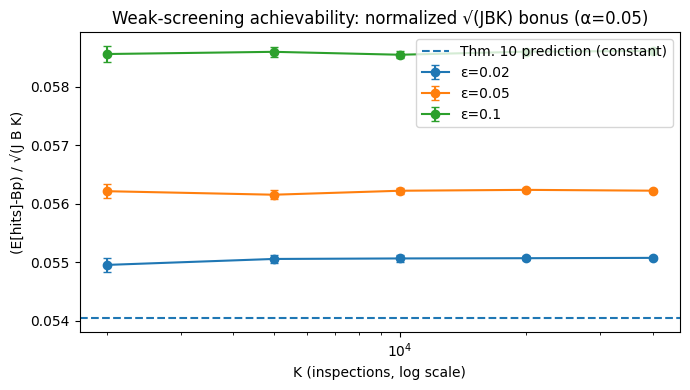

Saved: /home/leiyo/GitHub/Attention-Constrained-Leaderless-Inference/result/figure/03_theorem10_achievability_weak_screening.pdf


In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
csv_path = ROOT / "result" / "table" / "03_theorem10_achievability_weak_screening.csv"
fig_path = ROOT / "result" / "figure" / "03_theorem10_achievability_weak_screening.pdf"

df = pd.read_csv(csv_path).sort_values(["eps", "K"])

plt.rcParams["pdf.fonttype"] = 42
plt.figure(figsize=(7,4))

for eps, g in df.groupby("eps"):
    g = g.sort_values("K")
    plt.errorbar(
        g["K"],
        g["norm_bonus"],
        yerr=2*g["norm_SE"],
        fmt="o-",
        capsize=3,
        label=f"ε={eps:g}",
    )

c_pred = float(df["theorem10_c_pred"].iloc[0])
c_ub = float(df["corollary11_converse_const"].iloc[0])
alpha = float(df["alpha"].iloc[0])

plt.axhline(c_pred, linestyle="--", label="Thm. 10 prediction (constant)")
# plt.axhline(c_ub, linestyle=":", label="Cor. 11 converse √(ln2/2)")

plt.xscale("log")
plt.xlabel("K (inspections, log scale)")
plt.ylabel("(E[hits]-Bp) / √(J B K)")
plt.title(f"Weak-screening achievability: normalized √(JBK) bonus (α={alpha:g})")
plt.legend()
plt.tight_layout()
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, format="pdf")
plt.show()

print("Saved:", fig_path)
